In [1]:
pip install tensorflow matplotlib

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
    --------------------------------------- 6.6/350.9 MB 33.6 MB/s eta 0:00:11
   - -------------------------------------- 11.8/350.9 MB 30.8 MB/s eta 0:00:12
   -- ------------------------------------- 19.7/350.9 MB 32.7 MB/s eta 0:00:11
   --- ------------------------------------ 28.0/350.9 MB 34.9 MB/s eta 0:00:10
   ---- ----------------------------------- 35.9/350.9 MB 35.1 MB/s eta 0:00:09
   ---- ----------------------------------- 42.2/350.9 MB 34.4 MB/s eta 0:00:09
   ----- ---------------------------------- 48.2/350.9 MB 33.4 MB/s eta 0:00:10
   ------ --------------------------------- 54.3/350.9 MB 32.9 MB/s eta 0:00:10
   ------ --------------------------------- 60.8/350.9 MB 32.6 MB/s eta 0:00:09
   ------- -------------------------------- 66.3/350.9 MB 32.0 MB/s eta 0:00:09
   -------- ------------------------------- 73.7/350.9 MB 32.2


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Epoch 1/5


c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3299 - loss: 2.1571 - val_accuracy: 0.5222 - val_loss: 1.9711
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6291 - loss: 1.7443 - val_accuracy: 0.7417 - val_loss: 1.4251
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8024 - loss: 1.1589 - val_accuracy: 0.8444 - val_loss: 0.8868
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8740 - loss: 0.7030 - val_accuracy: 0.9000 - val_loss: 0.5369
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9019 - loss: 0.4728 - val_accuracy: 0.9083 - val_loss: 0.3857
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9083 - loss: 0.3857 
Test Accuracy: 0.9083333611488342


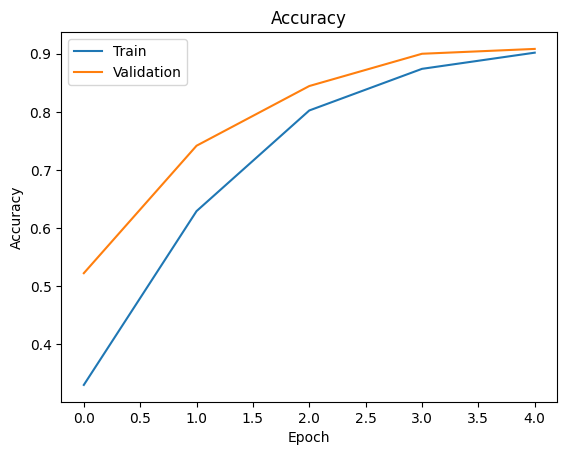

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from tensorflow.keras import layers, models

# Load dataset (offline, no download)
digits = load_digits()

X = digits.images
y = digits.target

# Normalize
X = X / 16.0

# Reshape for CNN (add channel dimension)
X = X.reshape(-1, 8, 8, 1)

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Build simple CNN
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(8,8,1)),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, models

# ==============================
# 📁 FOLDERS
# ==============================
images_folder = r"D:\IPCV\LAB-EXP-14\images"
result_folder = r"D:\IPCV\LAB-EXP-14\resultant_img"

os.makedirs(images_folder, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)

# ==============================
# 📊 LOAD DATASET (OFFLINE)
# ==============================
digits = load_digits()

X = digits.images
y = digits.target

# Normalize
X = X / 16.0

# Reshape for CNN
X = X.reshape(-1, 8, 8, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ==============================
# 💾 SAVE INPUT IMAGES
# ==============================
for i in range(5):
    plt.imshow(X[i].reshape(8,8), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
    
    plt.savefig(os.path.join(images_folder, f"input_{i}.png"))
    plt.close()

# ==============================
# 🧠 BUILD CNN MODEL
# ==============================
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(8,8,1)),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==============================
# 🚀 TRAIN MODEL
# ==============================
history = model.fit(X_train, y_train, epochs=5,
                    validation_data=(X_test, y_test))

# ==============================
# 📊 SAVE ACCURACY GRAPH
# ==============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.savefig(os.path.join(result_folder, "accuracy_plot.png"))
plt.close()

# ==============================
# 🔮 SAVE PREDICTIONS
# ==============================
predictions = model.predict(X_test)

for i in range(5):
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    
    pred_label = np.argmax(predictions[i])
    actual_label = y_test[i]
    
    plt.title(f"Pred: {pred_label}, Actual: {actual_label}")
    plt.axis('off')
    
    plt.savefig(os.path.join(result_folder, f"prediction_{i}.png"))
    plt.close()

# ==============================
# 📄 SAVE RESULT TEXT
# ==============================
loss, acc = model.evaluate(X_test, y_test)

with open(os.path.join(result_folder, "result.txt"), "w") as f:
    f.write(f"Test Accuracy: {acc}")

print("✅ All files saved successfully!")

Epoch 1/5


c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1942 - loss: 2.2488 - val_accuracy: 0.2917 - val_loss: 2.1681
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4294 - loss: 2.0413 - val_accuracy: 0.5694 - val_loss: 1.8639
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7063 - loss: 1.5898 - val_accuracy: 0.7528 - val_loss: 1.3155
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8434 - loss: 1.0182 - val_accuracy: 0.8500 - val_loss: 0.8235
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8838 - loss: 0.6455 - val_accuracy: 0.8944 - val_loss: 0.5567
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8944 - loss: 0.5567 
✅ All files saved successfully!
